# RA: 24011150

In [281]:
from itertools import product
import random
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

params = {'legend.fontsize': 20,
          'figure.figsize': (15,5),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'xtick.labelsize': 20,
          'ytick.labelsize': 20}

### Questão 1 e 2
> Para facilitar, eu fiz o que se pede na questão 1 e 2 na mesma célula.

In [282]:
def distanciaEuclidiana(ponto_atual, ponto_referencia):
    dx = ponto_atual[0] - ponto_referencia[0][0]
    dy = ponto_atual[1] - ponto_referencia[0][1]
    return pow(dx,2) + pow(dy,2)

Posição do ponto amarelo:
X: 3.6135461162708804
Y: 3.227127276655625

Para r = 0.3:
Azuis: 0
Vermelhos: 0
Grupo do padrão amarelo: Decisão inconclusiva: Nenhum dentro do raio de 0.3


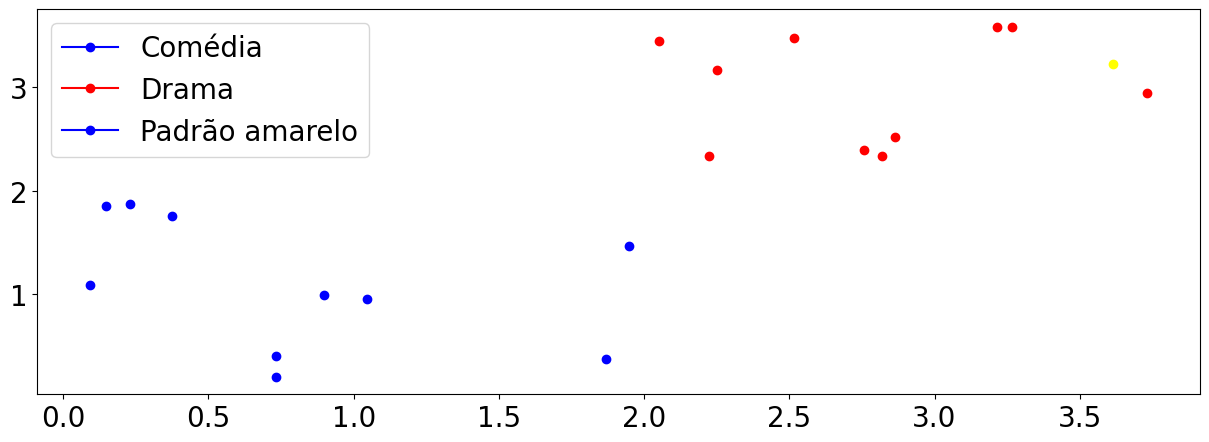

In [283]:
dots_1 = [(random.random() * 2.0, random.random() * 2.0) for _ in range(10)]
dots_2 = [((random.random() * 2.0) + 2.0, (random.random() * 2.0) + 2.0) for _ in range(10)]
dot_3 = [((random.random() * 2.0) + 2.0, (random.random() * 2.0) + 2.0)]

def distanciaComRaio(raio, grupo1, grupo2, grupo3):
    countComedia = 0
    countDrama = 0

    for ponto in grupo1:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countComedia += 1

    for ponto in grupo2:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countDrama += 1

    if countComedia > countDrama:
        grupo = "Comédia"
    elif countDrama > countComedia:
        grupo = "Drama"
    elif countDrama == 0 and countComedia == 0:
        grupo = "Decisão inconclusiva: Nenhum dentro do raio de " + str(raio) 
    else:
        grupo = "Decisão inconclusiva: Mesma quantidade dentro do raio de " + str(raio)

    return grupo, countComedia, countDrama

pylab.rcParams.update(params)
for i in range(len(dots_1)):
    plt.plot(dots_1[i][0], dots_1[i][1], c='blue', marker='o')
    plt.plot(dots_2[i][0], dots_2[i][1], c='red', marker='o')

plt.plot(dot_3[0][0], dot_3[0][1], c='yellow', marker='o')
plt.legend(['Comédia', 'Drama', 'Padrão amarelo'])

print("Posição do ponto amarelo:" + "\nX: " + str(dot_3[0][0]) + "\nY: " + str(dot_3[0][1]))

raio = 0.3
grupo, countComedia, countDrama = distanciaComRaio(raio, dots_1, dots_2, dot_3)
print("\nPara r = " + str(raio) + ":")
print("Azuis:", countComedia)
print("Vermelhos:", countDrama)
print("Grupo do padrão amarelo:", grupo)



plt.show()

###  Questão 3

#### Definindo pontos

In [284]:
dots_1 = [(random.random() * 2.0, random.random() * 2.0) for _ in range(25)]
dots_2 = [(random.random() * 2.0, random.random() * 2.0) for _ in range(25)]
dots_3 = [(random.random() * 2.0, random.random() * 2.0) for _ in range(3)]

#### Funções de distância

In [285]:
def distanciaComRaio(raio, grupo1, grupo2, grupo3):
    countFiccao = 0
    countAcao = 0

    for ponto in grupo1:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countFiccao += 1

    for ponto in grupo2:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countAcao += 1

    if countFiccao > countAcao:
        grupo = "Ficção Científica"
    elif countAcao > countFiccao:
        grupo = "Ação"
    elif countAcao == 0 and countFiccao == 0:
        raio += 0.1
        print("Aumentando raio para " + str(raio) + " pois não haviam dados suficientes.")
        grupo, countFiccao, countAcao = distanciaComRaio(raio, grupo1, grupo2, grupo3)
    elif countAcao == countFiccao:
        raio+= 0.1
        print("Aumentando raio para " + str(raio) + " pois não haviam dados suficientes para desempate.")
        grupo, countFiccao, countAcao = distanciaComRaio(raio, grupo1, grupo2, grupo3)
    else:
        grupo = "Decisão inconclusiva." + str(raio)

    return grupo, countFiccao, countAcao

def distanciaComRaioSemDesempate(raio, grupo1, grupo2, grupo3):
    countFiccao = 0
    countAcao = 0

    for ponto in grupo1:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countFiccao += 1

    for ponto in grupo2:
        d2 = distanciaEuclidiana(ponto, grupo3)
        if d2 <= pow(raio,2):
            countAcao += 1

    if countFiccao > countAcao:
        grupo = "Ficção Científica"
    elif countAcao > countFiccao:
        grupo = "Ação"
    elif countAcao == 0 and countFiccao == 0:
        grupo = "Decisão inconclusiva: Nenhum dado dentro do raio."
    elif countAcao == countFiccao:
        grupo = "Decisão inconclusiva: Quantidade igual de dados dentro do raio."
    else:
        grupo = "Decisão inconclusiva." + str(raio)

    return grupo, countFiccao, countAcao

Classificação dos 3 clientes com raio 0.3):

Cliente 1
Posição: X = 0.9511738068392206 | Y = 1.6983178854353402
Ficção Científica: 2
Ação: 4
Classificação: Ação

Cliente 2
Posição: X = 0.39548318883389877 | Y = 0.7948344233967191
Ficção Científica: 4
Ação: 1
Classificação: Ficção Científica

Cliente 3
Posição: X = 1.1575108646798369 | Y = 1.2571561556638913
Ficção Científica: 3
Ação: 1
Classificação: Ficção Científica



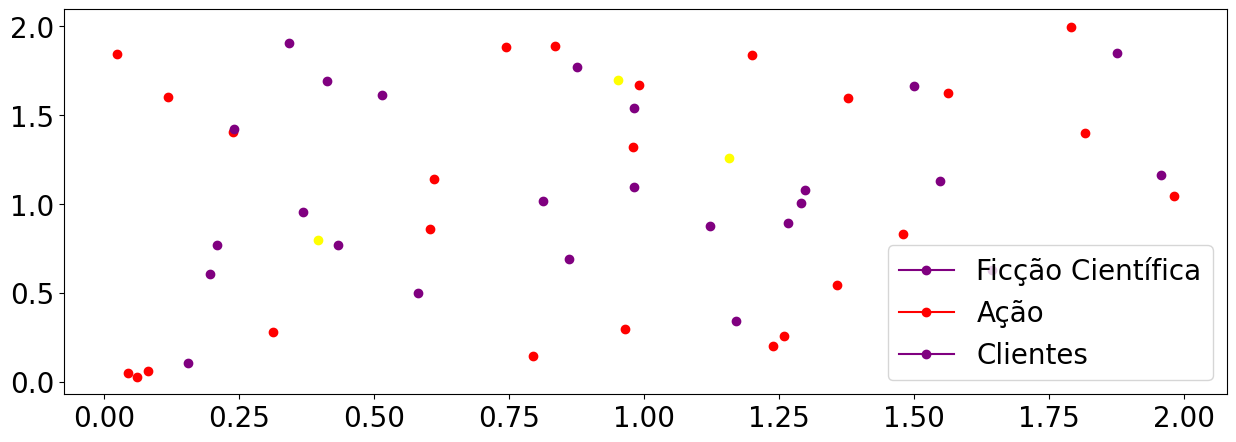

In [286]:
raio = 0.3

pylab.rcParams.update(params)
for i in range(len(dots_1)):
    plt.plot(dots_1[i][0], dots_1[i][1], c='purple', marker='o')
    plt.plot(dots_2[i][0], dots_2[i][1], c='red', marker='o')

for i in range(len(dots_3)):
    plt.plot(dots_3[i][0], dots_3[i][1], c='yellow', marker='o')

plt.legend(['Ficção Científica', 'Ação', 'Clientes'])

print("Classificação dos 3 clientes com raio " + str(raio) + "):\n")
for i in range(len(dots_3)):
    grupo, countFiccao, countAcao = distanciaComRaio(raio, dots_1, dots_2, [dots_3[i]])
    print("Cliente", i + 1)
    print("Posição: X =", dots_3[i][0], "| Y =", dots_3[i][1])
    print("Ficção Científica:", countFiccao)
    print("Ação:", countAcao)
    print("Classificação:", grupo)
    print()

plt.show()